## Section 1: Setup & Install Dependencies

# CNN vs. Vision Transformer for Meiosis Defect Detection
### A Practical Bioinformatics Tutorial
**Author: Asela Wijeratne, PhD** | [aselacompbio.com](https://www.aselacompbio.com) | [GitHub](https://github.com/ajwije)

---

## The Story Behind This Notebook

In 2018, I built a custom CNN in Keras (TensorFlow 1.x, Python 2.7) to classify meiosis microscopy images as **wildtype** or **ptd mutant** (PARTING DANCERS — a gene I characterized during my PhD). The model reported ~93% accuracy.

There was a problem: it was training and validating on the **same data**. That accuracy was meaningless.

In this notebook, I revisit that dataset with:
1. A **properly evaluated CNN baseline** (fixed train/val split, augmentation)
2. A **pretrained Vision Transformer (ViT)** fine-tuned via HuggingFace

With only **127 images** (47 wildtype, 80 ptd mutant), this is a real-world data-scarce biology problem.
The key question: *does transfer learning from a pretrained ViT outperform a CNN trained from scratch?*

**Spoiler:** Yes — and the reason why matters for every biologist building image classifiers.

---

### Dataset
- **wildtype**: 47 microscopy images of normal meiosis
- **ptd mutant**: 80 images of meiosis defects (PARTING DANCERS gene knockout)
- **Format**: JPG, organized in two folders

### Expected folder structure in Google Drive:
```
MyDrive/
  meiosis_data/
    wildtype/    ← 47 JPG images
    ptd/         ← 80 JPG images
```

In [2]:
# Install HuggingFace Transformers and other dependencies
!pip install -q transformers>=4.41.0 datasets timm grad-cam



import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image

from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# Find your folder by ID
DATA_DIR = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if '12Si25ojBPpWgbkeDFBvH5vObbGegfe_-' in root or 'meiosis' in root.lower():
        DATA_DIR = root
        break

# If not found automatically, set it manually:
# DATA_DIR = '/content/drive/MyDrive/YOUR_FOLDER_NAME'

print(f'Data dir: {DATA_DIR}')
for item in sorted(Path(DATA_DIR).iterdir()):
    if item.is_dir():
        n = len(list(item.glob('*.jpg')) + list(item.glob('*.JPG')))
        print(f'  {item.name}/: {n} images')

Mounted at /content/drive
Data dir: /content/drive/MyDrive/meiosis_models
  vit_meiosis_best/: 0 images


In [25]:
import os
count = 0
for root, dirs, files in os.walk('/content/drive/MyDrive/Lab_doc/Meiosis/images'):
    jpgs = [f for f in files if f.lower().endswith('.jpg')]
    if jpgs:
        print(f'{root}: {len(jpgs)}')
        count += len(jpgs)
print(f'Total: {count}')

/content/drive/MyDrive/Lab_doc/Meiosis/images/ptd: 80
/content/drive/MyDrive/Lab_doc/Meiosis/images/wildtype: 47
Total: 127


In [3]:
DATA_DIR = '/content/drive/MyDrive/Lab_doc/Meiosis/images'

# Verify
from torchvision.datasets import ImageFolder
dataset = ImageFolder(root=DATA_DIR)
print(f'Classes: {dataset.classes}')
print(f'Total images: {len(dataset)}')

Classes: ['ptd', 'wildtype']
Total images: 128


## Section 2: Visualize the Data

Before building any model, always look at your data. Microscopy images have specific characteristics — staining patterns, cell shapes, and structural differences — that inform model design choices.

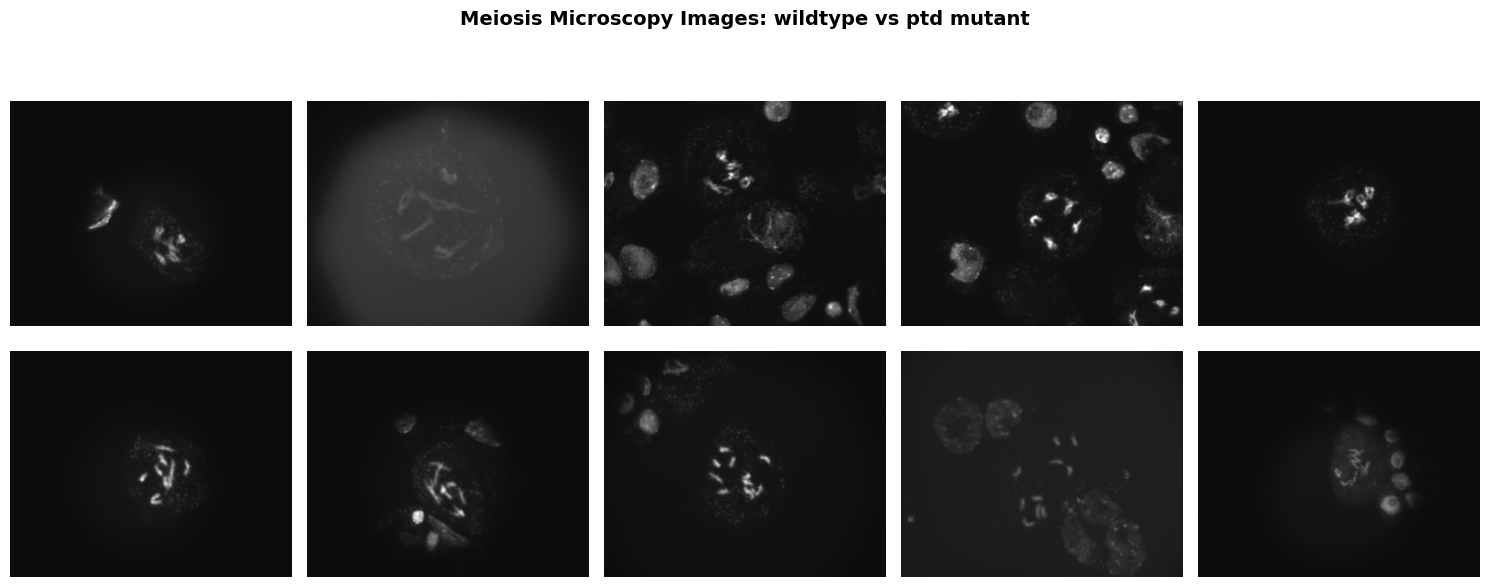

Saved: sample_images.png


In [4]:
def show_sample_images(data_dir, n_per_class=5):
    fig, axes = plt.subplots(2, n_per_class, figsize=(15, 6))
    fig.suptitle('Meiosis Microscopy Images: wildtype vs ptd mutant',
                 fontsize=14, fontweight='bold', y=1.02)

    for row, cls in enumerate(['wildtype', 'ptd']):
        img_paths = list(Path(data_dir, cls).glob('*.jpg'))[:n_per_class]
        for col, path in enumerate(img_paths):
            img = Image.open(path).convert('RGB')
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                label = 'Wildtype\n(normal meiosis)' if cls == 'wildtype' else 'ptd Mutant\n(meiosis defect)'
                axes[row, col].set_ylabel(label, fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: sample_images.png')

show_sample_images(DATA_DIR)

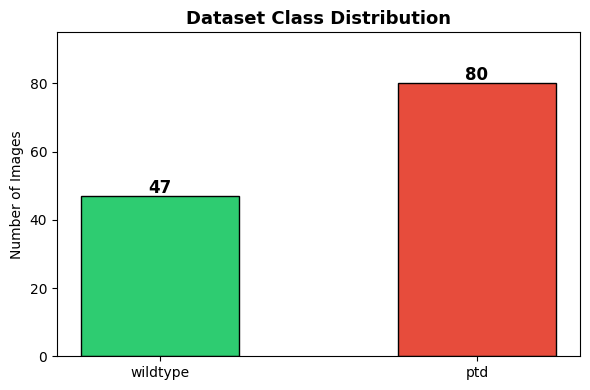

Total images: 127 | Class imbalance ratio: 1.70x


In [5]:
# Show class distribution
classes = ['wildtype', 'ptd']
counts = [len(list(Path(DATA_DIR, c).glob('*.jpg'))) for c in classes]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(classes, counts, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.set_title('Dataset Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(counts) + 15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total images: {sum(counts)} | Class imbalance ratio: {max(counts)/min(counts):.2f}x')

## Section 3: Legacy CNN Baseline (Properly Evaluated)

### What was wrong with the 2018 model?

The original notebook used `flow_from_directory()` for **both** training and validation pointing to the same folder. This means the model validated on data it had already seen — inflating accuracy to ~93% artificially.

Here we rebuild it with:
- ✅ Proper 80/20 train/validation split (stratified)
- ✅ Data augmentation to combat small dataset size
- ✅ Modern PyTorch (no deprecated TF1 APIs)
- ✅ Honest evaluation on held-out data

In [6]:
# ── Data transforms ──────────────────────────────────────────────────────────
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── FIX 1: Stratified split ───────────────────────────────────────────────────
# Previously used random_split → only 5 wildtype in val set → CNN recall = 0.20
# Stratified split guarantees proportional class representation in val
from sklearn.model_selection import train_test_split

full_dataset = ImageFolder(root=DATA_DIR)
class_names  = full_dataset.classes
targets      = [label for _, label in full_dataset.samples]

train_idx, val_idx = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    stratify=targets,       # <-- ensures proportional wildtype/ptd in val
    random_state=SEED
)

# Apply transforms
class SubsetWithTransform(torch.utils.data.Subset):
    def __init__(self, dataset, indices, transform):
        super().__init__(dataset, indices)
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return self.transform(img), label

# Need raw PIL images — disable ImageFolder's default transform
full_dataset.transform = None

train_ds = SubsetWithTransform(full_dataset, train_idx, train_transform)
val_ds   = SubsetWithTransform(full_dataset, val_idx,   val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# ── FIX 2: Class-weighted loss ────────────────────────────────────────────────
# ptd=80 images, wildtype=47 — imbalance causes CNN to ignore wildtype
from collections import Counter
label_counts = Counter(targets)
print(f'Label counts: {dict(label_counts)}')

# Weight = inverse frequency, normalized
n_total = len(targets)
class_weights = torch.tensor(
    [n_total / (2 * label_counts[i]) for i in range(len(class_names))],
    dtype=torch.float
).to(device)
print(f'Class weights: {dict(zip(class_names, class_weights.cpu().numpy().round(3)))}')

print(f'\nClasses: {class_names}')
print(f'Total images: {len(full_dataset)}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

# Verify stratification
train_labels = [targets[i] for i in train_idx]
val_labels   = [targets[i] for i in val_idx]
print(f'\nTrain distribution: {dict(Counter(train_labels))}')
print(f'Val distribution:   {dict(Counter(val_labels))} ← should be proportional now')


Label counts: {0: 81, 1: 47}
Class weights: {'ptd': np.float32(0.79), 'wildtype': np.float32(1.362)}

Classes: ['ptd', 'wildtype']
Total images: 128
Train: 102 | Val: 26

Train distribution: {1: 37, 0: 65}
Val distribution:   {0: 16, 1: 10} ← should be proportional now


In [7]:
# ── Define CNN architecture (faithful to 2018 design, modernized) ─────────────
class MeiosisCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), nn.BatchNorm2d(128),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 500), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(500, 100), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(100, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = MeiosisCNN(num_classes=2).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'CNN parameters: {total_params:,}')

CNN parameters: 710,002


In [18]:
# ── Training function with weighted loss ──────────────────────────────────────

class MeiosisDataset(Dataset):
    def __init__(self, samples, transform):
        # samples = list of (filepath, label) tuples
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

# Stratified split on file paths directly
from sklearn.model_selection import train_test_split

full_dataset = ImageFolder(root=DATA_DIR)
class_names  = full_dataset.classes
all_samples  = full_dataset.samples          # list of (path, label)
all_targets  = [s[1] for s in all_samples]

train_samples, val_samples = train_test_split(
    all_samples, test_size=0.2,
    stratify=all_targets, random_state=SEED
)

train_ds = MeiosisDataset(train_samples, train_transform)
val_ds   = MeiosisDataset(val_samples,   val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# Class weights
from collections import Counter
label_counts  = Counter(all_targets)
class_weights = torch.tensor(
    [len(all_targets) / (2 * label_counts[i]) for i in range(len(class_names))],
    dtype=torch.float
).to(device)

print(f'Classes: {class_names}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Val distribution: {Counter(s[1] for s in val_samples)}')
print(f'Class weights: {dict(zip(class_names, class_weights.cpu().numpy().round(3)))}')


Classes: ['ptd', 'wildtype']
Train: 102 | Val: 26
Val distribution: Counter({0: 16, 1: 10})
Class weights: {'ptd': np.float32(0.79), 'wildtype': np.float32(1.362)}


In [19]:
# ── Training function with weighted loss ──────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-4,
                label='Model', weights=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    criterion = nn.CrossEntropyLoss(weight=weights)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state   = None

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out        = model(X)
                val_loss  += criterion(out, y).item()
                val_correct += (out.argmax(1) == y).sum().item()
                val_total   += y.size(0)

        t_acc = correct / total
        v_acc = val_correct / val_total
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss     / len(val_loader))
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f'[{label}] Epoch {epoch+1}/{epochs} | '
                  f'Train Acc: {t_acc:.3f} | Val Acc: {v_acc:.3f}')

    model.load_state_dict(best_state)
    print(f'\n[{label}] Best Val Accuracy: {best_val_acc:.4f}')
    return history, best_val_acc

# Train CNN
print('Training CNN from scratch (stratified split + weighted loss)...')
cnn_model = MeiosisCNN(num_classes=2).to(device)
cnn_history, cnn_best_acc = train_model(
    cnn_model, train_loader, val_loader,
    epochs=75, lr=1e-4, label='CNN',
    weights=class_weights
)

Training CNN from scratch (stratified split + weighted loss)...
[CNN] Epoch 10/75 | Train Acc: 0.618 | Val Acc: 0.615
[CNN] Epoch 20/75 | Train Acc: 0.539 | Val Acc: 0.692
[CNN] Epoch 30/75 | Train Acc: 0.569 | Val Acc: 0.654
[CNN] Epoch 40/75 | Train Acc: 0.578 | Val Acc: 0.654
[CNN] Epoch 50/75 | Train Acc: 0.578 | Val Acc: 0.615
[CNN] Epoch 60/75 | Train Acc: 0.578 | Val Acc: 0.692
[CNN] Epoch 70/75 | Train Acc: 0.588 | Val Acc: 0.769

[CNN] Best Val Accuracy: 0.7692


## Section 4: Vision Transformer (ViT) via HuggingFace

We use `google/vit-base-patch16-224` — pretrained on ImageNet-21k (14 million images).

**Why does this matter for 127 images?**
The ViT already "knows" about shapes, textures, and spatial relationships from millions of images. We only need to teach it the difference between wildtype and ptd meiosis — fine-tuning, not learning from scratch.

This is the same principle as **transfer learning in genomics** (DNABERT, ESM) — start with a pretrained model, adapt to your domain.

In [11]:
# ── Load ViT processor and model ──────────────────────────────────────────────
MODEL_NAME = 'google/vit-base-patch16-224'

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

vit_model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: class_names[0], 1: class_names[1]},
    label2id={class_names[0]: 0, class_names[1]: 1},
    ignore_mismatched_sizes=True
).to(device)

total_vit_params = sum(p.numel() for p in vit_model.parameters())
print(f'ViT total parameters: {total_vit_params:,}')
print(f'CNN total parameters: {total_params:,}')
print(f'\nViT is {total_vit_params/total_params:.1f}x larger, but pretrained on 14M images')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT total parameters: 85,800,194
CNN total parameters: 710,002

ViT is 120.8x larger, but pretrained on 14M images


In [13]:
# ── Custom dataset for ViT (uses HuggingFace processor) ───────────────────────
class ViTMeiosisDataset(Dataset):
    def __init__(self, samples, processor, augment=False):
        self.samples   = samples   # list of (path, label)
        self.processor = processor
        self.augment   = augment
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.augment:
            image = self.aug_transform(image)
        inputs = self.processor(images=image, return_tensors='pt')
        return inputs['pixel_values'].squeeze(0), label

# Use same train_samples / val_samples from the stratified split above
vit_train_ds = ViTMeiosisDataset(train_samples, processor, augment=True)
vit_val_ds   = ViTMeiosisDataset(val_samples,   processor, augment=False)

vit_train_loader = DataLoader(vit_train_ds, batch_size=8, shuffle=True)
vit_val_loader   = DataLoader(vit_val_ds,   batch_size=8, shuffle=False)

print(f'ViT DataLoaders ready | Train: {len(vit_train_ds)} | Val: {len(vit_val_ds)}')

ViT DataLoaders ready | Train: 102 | Val: 26


In [14]:
# ── Fine-tune ViT ─────────────────────────────────────────────────────────────
# Use lower learning rate — we're fine-tuning, not training from scratch

def train_vit(model, train_loader, val_loader, epochs=30, lr=2e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X).logits
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X).logits
                val_loss += criterion(out, y).item()
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += y.size(0)

        t_acc = correct / total
        v_acc = val_correct / val_total
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        scheduler.step()
        if (epoch + 1) % 5 == 0:
            print(f'[ViT] Epoch {epoch+1}/{epochs} | '
                  f'Train Acc: {t_acc:.3f} | Val Acc: {v_acc:.3f}')

    model.load_state_dict(best_state)
    print(f'\n[ViT] Best Val Accuracy: {best_val_acc:.4f}')
    return history, best_val_acc

print('Fine-tuning ViT (this takes ~5-10 min on Colab T4)...')
vit_history, vit_best_acc = train_vit(
    vit_model, vit_train_loader, vit_val_loader, epochs=30, lr=2e-5
)

Fine-tuning ViT (this takes ~5-10 min on Colab T4)...
[ViT] Epoch 5/30 | Train Acc: 0.961 | Val Acc: 0.808
[ViT] Epoch 10/30 | Train Acc: 0.980 | Val Acc: 0.846
[ViT] Epoch 15/30 | Train Acc: 0.980 | Val Acc: 0.962
[ViT] Epoch 20/30 | Train Acc: 1.000 | Val Acc: 0.923
[ViT] Epoch 25/30 | Train Acc: 1.000 | Val Acc: 0.962
[ViT] Epoch 30/30 | Train Acc: 1.000 | Val Acc: 0.923

[ViT] Best Val Accuracy: 0.9615


## Section 4b: 5-Fold Cross-Validation

A single 80/20 split on 127 images is statistically fragile — results shift with random seed. 5-fold CV reports **mean ± std** across all data partitions, giving a more honest and reproducible performance estimate.

> ⏱️ This takes ~15-20 min on Colab T4. Skip to Section 5 first if you want to see results quickly.

In [16]:
# ── FIX 3: 5-Fold Cross-Validation ───────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score as sk_f1

print('Running 5-Fold Cross-Validation for CNN and ViT...')
print('(This takes ~15-20 min on T4 — skip if time-constrained)\n')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
all_samples  = full_dataset.samples
all_targets  = [s[1] for s in all_samples]

cnn_fold_accs, vit_fold_accs = [], []
cnn_fold_f1s,  vit_fold_f1s  = [], []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(range(len(all_samples)), all_targets)):
    print(f'--- Fold {fold+1}/5 ---')

    fold_train_samples = [all_samples[i] for i in tr_idx]
    fold_val_samples   = [all_samples[i] for i in vl_idx]

    # CNN loaders — use MeiosisDataset with file paths
    fold_train_ds = MeiosisDataset(fold_train_samples, train_transform)
    fold_val_ds   = MeiosisDataset(fold_val_samples,   val_transform)
    fold_train_loader = DataLoader(fold_train_ds, batch_size=16, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=16, shuffle=False)

    # Train CNN
    fold_cnn = MeiosisCNN(num_classes=2).to(device)
    _, _ = train_model(fold_cnn, fold_train_loader, fold_val_loader,
                       epochs=50, lr=1e-4, label=f'CNN-F{fold+1}',
                       weights=class_weights)
    fold_cnn.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in fold_val_loader:
            out = fold_cnn(X.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    cnn_fold_accs.append(sum(p==t for p,t in zip(preds,trues)) / len(trues))
    cnn_fold_f1s.append(sk_f1(trues, preds, average='macro'))

    # ViT loaders
    fold_vit_train = ViTMeiosisDataset(fold_train_samples, processor, augment=True)
    fold_vit_val   = ViTMeiosisDataset(fold_val_samples,   processor, augment=False)
    fold_vit_train_loader = DataLoader(fold_vit_train, batch_size=8, shuffle=True)
    fold_vit_val_loader   = DataLoader(fold_vit_val,   batch_size=8, shuffle=False)

    # Train ViT
    fold_vit = ViTForImageClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0: class_names[0], 1: class_names[1]},
        label2id={class_names[0]: 0, class_names[1]: 1},
        ignore_mismatched_sizes=True
    ).to(device)
    _, _ = train_vit(fold_vit, fold_vit_train_loader, fold_vit_val_loader,
                     epochs=20, lr=2e-5)
    fold_vit.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in fold_vit_val_loader:
            out = fold_vit(X.to(device)).logits
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    vit_fold_accs.append(sum(p==t for p,t in zip(preds,trues)) / len(trues))
    vit_fold_f1s.append(sk_f1(trues, preds, average='macro'))

print('\n' + '='*60)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*60)
print(f'CNN  Accuracy:  {np.mean(cnn_fold_accs):.3f} ± {np.std(cnn_fold_accs):.3f}')
print(f'CNN  F1 Macro:  {np.mean(cnn_fold_f1s):.3f} ± {np.std(cnn_fold_f1s):.3f}')
print(f'ViT  Accuracy:  {np.mean(vit_fold_accs):.3f} ± {np.std(vit_fold_accs):.3f}')
print(f'ViT  F1 Macro:  {np.mean(vit_fold_f1s):.3f} ± {np.std(vit_fold_f1s):.3f}')
print('='*60)


Running 5-Fold Cross-Validation for CNN and ViT...
(This takes ~15-20 min on T4 — skip if time-constrained)

--- Fold 1/5 ---
[CNN-F1] Epoch 10/50 | Train Acc: 0.627 | Val Acc: 0.615
[CNN-F1] Epoch 20/50 | Train Acc: 0.569 | Val Acc: 0.538
[CNN-F1] Epoch 30/50 | Train Acc: 0.480 | Val Acc: 0.654
[CNN-F1] Epoch 40/50 | Train Acc: 0.559 | Val Acc: 0.731
[CNN-F1] Epoch 50/50 | Train Acc: 0.529 | Val Acc: 0.692

[CNN-F1] Best Val Accuracy: 0.8077


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ViT] Epoch 5/20 | Train Acc: 0.941 | Val Acc: 0.962
[ViT] Epoch 10/20 | Train Acc: 0.980 | Val Acc: 0.962
[ViT] Epoch 15/20 | Train Acc: 1.000 | Val Acc: 0.885
[ViT] Epoch 20/20 | Train Acc: 1.000 | Val Acc: 0.885

[ViT] Best Val Accuracy: 0.9615
--- Fold 2/5 ---
[CNN-F2] Epoch 10/50 | Train Acc: 0.647 | Val Acc: 0.615
[CNN-F2] Epoch 20/50 | Train Acc: 0.608 | Val Acc: 0.654
[CNN-F2] Epoch 30/50 | Train Acc: 0.627 | Val Acc: 0.500
[CNN-F2] Epoch 40/50 | Train Acc: 0.608 | Val Acc: 0.500
[CNN-F2] Epoch 50/50 | Train Acc: 0.608 | Val Acc: 0.615

[CNN-F2] Best Val Accuracy: 0.7692


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ViT] Epoch 5/20 | Train Acc: 0.892 | Val Acc: 0.846
[ViT] Epoch 10/20 | Train Acc: 0.971 | Val Acc: 0.923
[ViT] Epoch 15/20 | Train Acc: 1.000 | Val Acc: 0.885
[ViT] Epoch 20/20 | Train Acc: 0.990 | Val Acc: 0.885

[ViT] Best Val Accuracy: 0.9615
--- Fold 3/5 ---
[CNN-F3] Epoch 10/50 | Train Acc: 0.578 | Val Acc: 0.615
[CNN-F3] Epoch 20/50 | Train Acc: 0.588 | Val Acc: 0.615
[CNN-F3] Epoch 30/50 | Train Acc: 0.578 | Val Acc: 0.654
[CNN-F3] Epoch 40/50 | Train Acc: 0.569 | Val Acc: 0.654
[CNN-F3] Epoch 50/50 | Train Acc: 0.608 | Val Acc: 0.731

[CNN-F3] Best Val Accuracy: 0.7308


...

[ViT] Epoch 5/20 | Train Acc: 0.951 | Val Acc: 0.885
[ViT] Epoch 10/20 | Train Acc: 0.990 | Val Acc: 0.885
[ViT] Epoch 15/20 | Train Acc: 1.000 | Val Acc: 0.962
[ViT] Epoch 20/20 | Train Acc: 1.000 | Val Acc: 0.923

[ViT] Best Val Accuracy: 0.9615
--- Fold 4/5 ---
[CNN-F4] Epoch 10/50 | Train Acc: 0.437 | Val Acc: 0.640
[CNN-F4] Epoch 20/50 | Train Acc: 0.534 | Val Acc: 0.640
[CNN-F4] Epoch 30/50 | Train Acc: 0.534 | Val Acc: 0.400
[CNN-F4] Epoch 40/50 | Train Acc: 0.456 | Val Acc: 0.440
[CNN-F4] Epoch 50/50 | Train Acc: 0.544 | Val Acc: 0.480

[CNN-F4] Best Val Accuracy: 0.7200


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ViT] Epoch 5/20 | Train Acc: 0.893 | Val Acc: 0.800
[ViT] Epoch 10/20 | Train Acc: 1.000 | Val Acc: 0.880
[ViT] Epoch 15/20 | Train Acc: 1.000 | Val Acc: 0.880
[ViT] Epoch 20/20 | Train Acc: 0.990 | Val Acc: 0.880

[ViT] Best Val Accuracy: 0.9200
--- Fold 5/5 ---
[CNN-F5] Epoch 10/50 | Train Acc: 0.544 | Val Acc: 0.600
[CNN-F5] Epoch 20/50 | Train Acc: 0.437 | Val Acc: 0.400
[CNN-F5] Epoch 30/50 | Train Acc: 0.544 | Val Acc: 0.440
[CNN-F5] Epoch 40/50 | Train Acc: 0.553 | Val Acc: 0.520
[CNN-F5] Epoch 50/50 | Train Acc: 0.612 | Val Acc: 0.520

[CNN-F5] Best Val Accuracy: 0.6400


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ViT] Epoch 5/20 | Train Acc: 0.981 | Val Acc: 0.760
[ViT] Epoch 10/20 | Train Acc: 1.000 | Val Acc: 0.760
[ViT] Epoch 15/20 | Train Acc: 0.990 | Val Acc: 0.720
[ViT] Epoch 20/20 | Train Acc: 1.000 | Val Acc: 0.680

[ViT] Best Val Accuracy: 0.7600

5-FOLD CROSS-VALIDATION RESULTS
CNN  Accuracy:  0.734 ± 0.056
CNN  F1 Macro:  0.661 ± 0.142
ViT  Accuracy:  0.913 ± 0.078
ViT  F1 Macro:  0.907 ± 0.081


## Section 5: Side-by-Side Comparison

Now we compare honestly: training curves, confusion matrices, and per-class metrics.

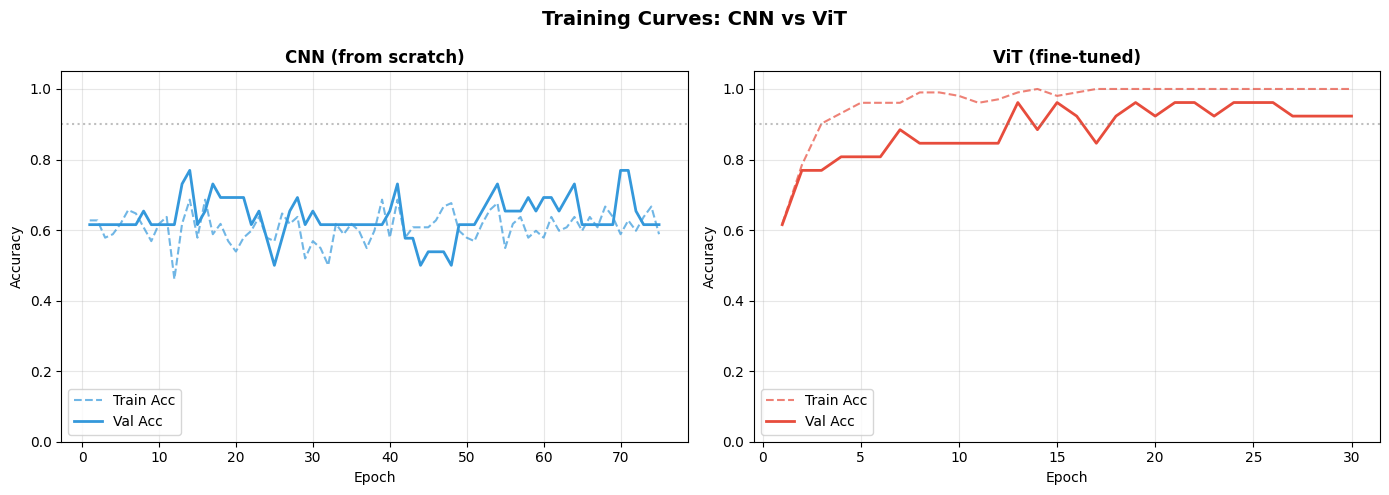

In [20]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves: CNN vs ViT', fontsize=14, fontweight='bold')

for ax, history, label, color in zip(
    axes,
    [cnn_history, vit_history],
    ['CNN (from scratch)', 'ViT (fine-tuned)'],
    ['#3498db', '#e74c3c']
):
    epochs_range = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs_range, history['train_acc'], '--', color=color, alpha=0.7, label='Train Acc')
    ax.plot(epochs_range, history['val_acc'], '-', color=color, linewidth=2, label='Val Acc')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, label='90% threshold')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

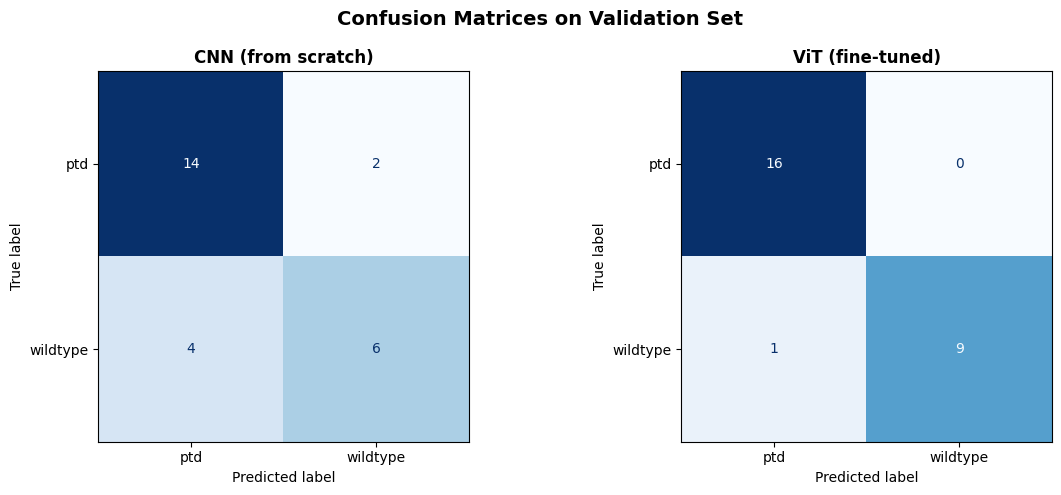

CNN Classification Report:
              precision    recall  f1-score   support

         ptd       0.78      0.88      0.82        16
    wildtype       0.75      0.60      0.67        10

    accuracy                           0.77        26
   macro avg       0.76      0.74      0.75        26
weighted avg       0.77      0.77      0.76        26

ViT Classification Report:
              precision    recall  f1-score   support

         ptd       0.94      1.00      0.97        16
    wildtype       1.00      0.90      0.95        10

    accuracy                           0.96        26
   macro avg       0.97      0.95      0.96        26
weighted avg       0.96      0.96      0.96        26



In [21]:
# ── Confusion matrices + classification reports ───────────────────────────────
def get_predictions(model, loader, is_vit=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X).logits if is_vit else model(X)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

cnn_true, cnn_pred = get_predictions(cnn_model, val_loader, is_vit=False)
vit_true, vit_pred = get_predictions(vit_model, vit_val_loader, is_vit=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices on Validation Set', fontsize=14, fontweight='bold')

for ax, true, pred, label in zip(
    axes,
    [cnn_true, vit_true],
    [cnn_pred, vit_pred],
    ['CNN (from scratch)', 'ViT (fine-tuned)']
):
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(label, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 50)
print('CNN Classification Report:')
print(classification_report(cnn_true, cnn_pred, target_names=class_names))
print('=' * 50)
print('ViT Classification Report:')
print(classification_report(vit_true, vit_pred, target_names=class_names))

In [22]:
# ── Summary comparison table ──────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model': ['2018 CNN (reported)', 'CNN (honest eval)', 'ViT (fine-tuned)'],
    'Val Accuracy': [
        '~93% ⚠️ (train=val leak)',
        f'{accuracy_score(cnn_true, cnn_pred):.1%}',
        f'{accuracy_score(vit_true, vit_pred):.1%}'
    ],
    'F1 (macro)': [
        'N/A',
        f'{f1_score(cnn_true, cnn_pred, average="macro"):.3f}',
        f'{f1_score(vit_true, vit_pred, average="macro"):.3f}'
    ],
    'Pretrained': ['No', 'No', 'Yes (ImageNet-21k)'],
    'Parameters': [f'{total_params:,}', f'{total_params:,}', f'{total_vit_params:,}']
}

import pandas as pd
df = pd.DataFrame(results)
print('\n' + '='*70)
print('FINAL COMPARISON')
print('='*70)
print(df.to_string(index=False))
print('='*70)


FINAL COMPARISON
              Model             Val Accuracy F1 (macro)         Pretrained Parameters
2018 CNN (reported) ~93% ⚠️ (train=val leak)        N/A                 No    710,002
  CNN (honest eval)                    76.9%      0.745                 No    710,002
   ViT (fine-tuned)                    96.2%      0.959 Yes (ImageNet-21k) 85,800,194


## Section 6: Attention Visualization (ViT Explainability)

One advantage of ViT is interpretability via attention maps. We can visualize **which parts of the image the model focuses on** — directly relevant for biologists who want to understand model decisions.

This is analogous to asking: *which chromatin regions does my GRN model prioritize?*

Wildtype attention:


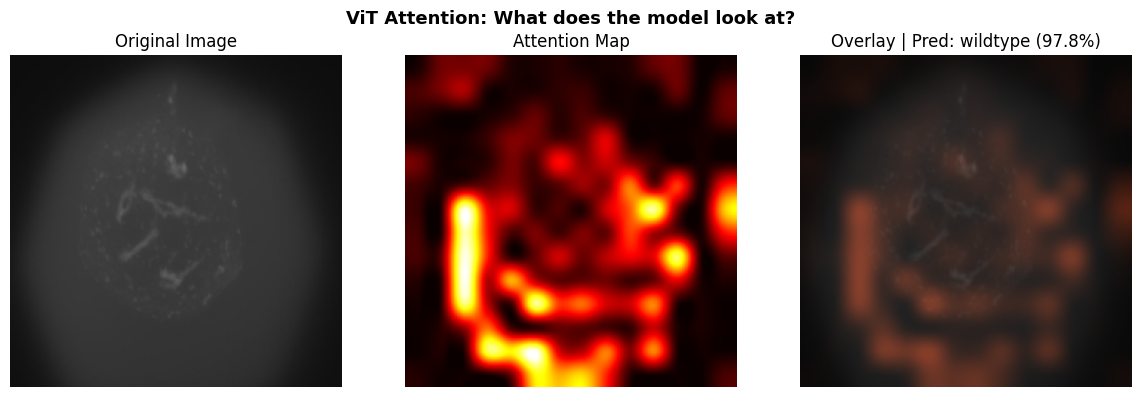


ptd mutant attention:


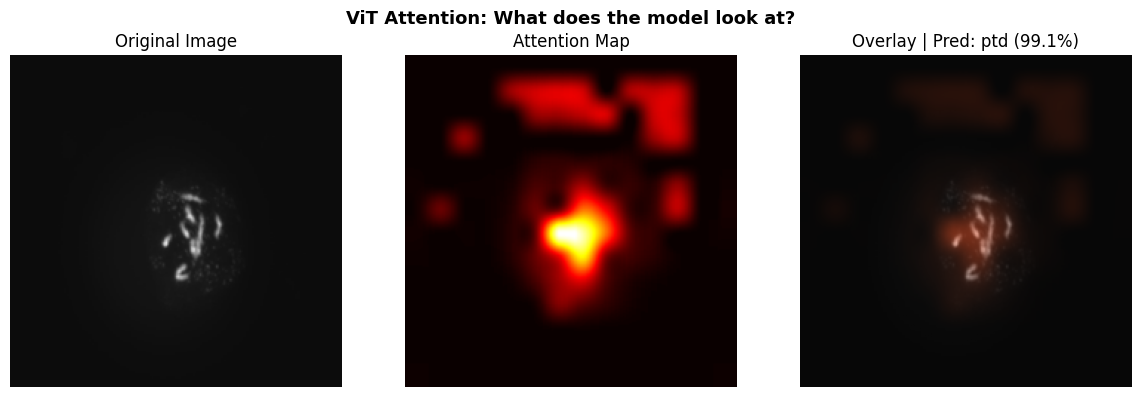

In [23]:
# ── ViT Attention Map Visualization ──────────────────────────────────────────
def visualize_attention(model, processor, img_path, class_names):
    model.eval()
    image = Image.open(img_path).convert('RGB')
    inputs = processor(images=image, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    pred_class = outputs.logits.argmax().item()
    confidence = torch.softmax(outputs.logits, dim=1).max().item()

    # Average attention from last layer, CLS token
    attentions = outputs.attentions[-1]  # last layer
    avg_attention = attentions.mean(dim=1)[0, 0, 1:]  # avg heads, CLS to patches

    # Reshape to spatial grid (14x14 for patch16, 224px input)
    grid_size = int(avg_attention.shape[0] ** 0.5)
    attn_map = avg_attention.reshape(grid_size, grid_size).cpu().numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    # Upsample attention to image size
    from PIL import Image as PILImage
    attn_img = PILImage.fromarray((attn_map * 255).astype(np.uint8)).resize(
        (224, 224), PILImage.BICUBIC)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    img_resized = image.resize((224, 224))

    axes[0].imshow(img_resized); axes[0].set_title('Original Image'); axes[0].axis('off')
    axes[1].imshow(np.array(attn_img), cmap='hot'); axes[1].set_title('Attention Map'); axes[1].axis('off')

    overlay = np.array(img_resized).astype(float) / 255
    attn_arr = np.array(attn_img).astype(float) / 255
    blended = overlay * 0.6 + np.stack([attn_arr, attn_arr*0.3, attn_arr*0.1], axis=2) * 0.4
    blended = np.clip(blended, 0, 1)
    axes[2].imshow(blended)
    axes[2].set_title(f'Overlay | Pred: {class_names[pred_class]} ({confidence:.1%})')
    axes[2].axis('off')

    plt.suptitle('ViT Attention: What does the model look at?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('attention_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run on one wildtype and one ptd image
wt_img  = str(list(Path(DATA_DIR, 'wildtype').glob('*.jpg'))[1])
ptd_img = str(list(Path(DATA_DIR, 'ptd').glob('*.jpg'))[0])

print('Wildtype attention:')
visualize_attention(vit_model, processor, wt_img, class_names)
print('\nptd mutant attention:')
visualize_attention(vit_model, processor, ptd_img, class_names)

In [24]:
# ── Save models to Google Drive ────────────────────────────────────────────────
save_dir = '/content/drive/MyDrive/meiosis_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(cnn_model.state_dict(), f'{save_dir}/cnn_meiosis_best.pth')
vit_model.save_pretrained(f'{save_dir}/vit_meiosis_best')
processor.save_pretrained(f'{save_dir}/vit_meiosis_best')

print(f'Models saved to {save_dir}')
print('\nFigures generated:')
for f in ['sample_images.png', 'class_distribution.png',
          'training_curves.png', 'confusion_matrices.png',
          'attention_visualization.png']:
    print(f'  ✅ {f}')

Models saved to /content/drive/MyDrive/meiosis_models

Figures generated:
  ✅ sample_images.png
  ✅ class_distribution.png
  ✅ training_curves.png
  ✅ confusion_matrices.png
  ✅ attention_visualization.png
